In [426]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.formula.api as smf
from lightgbm import LGBMRegressor
import sqlite3

import holidays
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.model_selection import ParameterSampler

In [41]:
conn = sqlite3.connect("../fietstellingen.db")

In [482]:
query = """
SELECT
    Site_ID,
    strftime('%Y-%m-%d %H:00:00', Start_Time) AS Start_Time,
    SUM(Count) AS Count
FROM traffic_counts
WHERE Count IS NOT NULL and Start_Time >= datetime('now', '-3 years')
GROUP BY
    Site_ID,
    strftime('%Y-%m-%d %H:00:00', Start_Time)
ORDER BY
    Site_ID,
    Start_Time
"""

df_h = pd.read_sql_query(query, conn)

In [483]:
df_h.isnull().sum()

Site_ID       0
Start_Time    0
Count         0
dtype: int64

In [484]:
df_h.describe()

,Count
count,3.615057e+06
mean,2.234158e+01
std,4.783364e+01
min,0.000000e+00
25%,2.000000e+00
50%,8.000000e+00
75%,2.300000e+01
max,9.901000e+03


In [485]:
df_h.dtypes

Site_ID           str
Start_Time        str
Count         float64
dtype: object

In [486]:
df_h["Start_Time"] = pd.to_datetime(df_h["Start_Time"])

In [487]:
df_daily = df_h.dropna(subset=["Count"]).set_index("Start_Time").groupby("Site_ID").resample("D").agg({"Count": "sum"}).reset_index()


In [488]:
df_daily["Count"].isna().sum()

np.int64(0)

In [489]:
features = [
    "Site_ID",
    "dayofweek",
    # "month",
    # "dayofyear",
    "is_weekend",
    "month_sin",
    "month_cos",
    # "doy_sin",
    # "doy_cos",
    "Is_Public_Holiday",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7"
]

target = "Count"

In [490]:
def add_time_features(data):
    data["dayofweek"] = data["Start_Time"].dt.dayofweek
    data["month"] = data["Start_Time"].dt.month
    data["dayofyear"] = data["Start_Time"].dt.dayofyear
    data["is_weekend"] = (data["dayofweek"] >= 5).astype(int)
    
    # yearly seasonality
    data["month_sin"] = np.sin(2 * np.pi * data["month"] / 12)
    data["month_cos"] = np.cos(2 * np.pi * data["month"] / 12)
    data["doy_sin"] = np.sin(2 * np.pi * data["dayofyear"] / 365)
    data["doy_cos"] = np.cos(2 * np.pi * data["dayofyear"] / 365)
    
    return data

def add_holiday_feature(df: pd.DataFrame) -> pd.DataFrame:
    ## Initialize the Belgian holiday calendar for your dataset's years
    years_in_data = df['Start_Time'].dt.year.unique().tolist()
    be_holidays = holidays.BE(years=years_in_data)
    ## Create a binary flag: 1 if it's a holiday, 0 if it's a normal day
    ## We convert Start_Time to just the date to match the holiday dictionary
    df['Is_Public_Holiday'] = df['Start_Time'].dt.date.apply(lambda x: 1 if x in be_holidays else 0)
    return df


def split_train_test(df, cutoff="2025-05-16",forecast_end="2025-11-16",years=2):
    cutoff = pd.Timestamp(cutoff)
    forecast_end = pd.Timestamp(forecast_end)

    train_start = cutoff - pd.DateOffset(years=years)

    train = df[(df["Start_Time"] >= train_start) & (df["Start_Time"] <= cutoff)]
    test_actual = df[(df["Start_Time"] > cutoff) & (df["Start_Time"] <= forecast_end)]

    train["Site_ID"] = train["Site_ID"].astype("category")

    return train, test_actual


def recursive_forecast_lgbm(model, history, future_dates, features):
    predictions = []

    sites = history["Site_ID"].unique()

    for date in future_dates:
        future_rows = pd.DataFrame({"Site_ID": sites, "Start_Time": date})

        future_rows = add_time_features(future_rows)
        future_rows = add_holiday_feature(future_rows)

        for lag in [1, 2, 3, 7]:
            lag_values = (
                history[history["Start_Time"] == date - pd.Timedelta(days=lag)]
                [["Site_ID", "Count"]]
                .rename(columns={"Count": f"lag_{lag}"})
            )

            future_rows = future_rows.merge(lag_values, on="Site_ID", how="left")

        future_rows = future_rows.dropna(subset=["lag_1", "lag_2", "lag_3", "lag_7"]).copy()
        future_rows["Site_ID"] = future_rows["Site_ID"].astype("category")
        future_rows["pred"] = model.predict(future_rows[features])

        # Count cannot be negative
        future_rows["pred"] = np.maximum(future_rows["pred"], 0)
        append_rows = future_rows[["Site_ID", "Start_Time", "pred"]].rename(columns={"pred": "Count"})

        history = pd.concat([history, append_rows], ignore_index=True)
        predictions.append(future_rows)

    return pd.concat(predictions, ignore_index=True)


def predict_count(lgbm_model,test_actual,df,cutoff="2025-05-16",forecast_end="2025-11-16"):

    future_dates = pd.date_range(
        start= pd.Timestamp(cutoff) + pd.Timedelta(days=1),
        end= pd.Timestamp(forecast_end),
        freq="D"
    )

    history = df[df["Start_Time"] <= cutoff][["Site_ID", "Start_Time", "Count"]].copy()

    pred_eval = recursive_forecast_lgbm(
        model=lgbm_model,
        history=history,
        future_dates=future_dates,
        features=features
    )

    eval_df = pred_eval.merge(
        test_actual[["Site_ID", "Start_Time", "Count"]],
        on=["Site_ID", "Start_Time"],
        how="inner"
    )

    eval_df = eval_df.rename(columns={"Count": "actual"})

    # daily error summary
    # eval_df["date"] = pd.to_datetime(eval_df["Start_Time"]).dt.date

    # daily_error_df = eval_df[["Site_ID", "Start_Time", "pred", "actual"]]
    # daily_error_df["error"] = daily_error_df["pred"] - daily_error_df["actual"]
    # daily_error_df["abs_error"] = daily_error_df["error"].abs()
    # daily_error_df = daily_error_df.sort_values(['Site_ID', 'Start_Time'])


    mae_lgbm = mean_absolute_error(eval_df["actual"], eval_df["pred"])
    rmse_lgbm = np.sqrt(mean_squared_error(eval_df["actual"], eval_df["pred"]))

    print("Recursive LightGBM MAE:", mae_lgbm)
    print("Recursive LightGBM RMSE:", rmse_lgbm)

    # return eval_df,daily_error_df
    return eval_df, mae_lgbm, rmse_lgbm


In [491]:
df_daily = add_time_features(df_daily)
df_daily = add_holiday_feature(df_daily)

In [492]:
df_daily["lag_1"] = df_daily.groupby("Site_ID")["Count"].shift(1)
df_daily["lag_2"] = df_daily.groupby("Site_ID")["Count"].shift(2)
df_daily["lag_3"] = df_daily.groupby("Site_ID")["Count"].shift(3)
df_daily["lag_7"] = df_daily.groupby("Site_ID")["Count"].shift(7)

df_model_daily = df_daily.dropna().copy()

In [517]:
df_model_daily.head()

,Site_ID,Start_Time,Count,dayofweek,month,dayofyear,is_weekend,month_sin,month_cos,doy_sin,doy_cos,Is_Public_Holiday,lag_1,lag_2,lag_3,lag_7
7,Location_Tag_1,2023-05-26,577.0,4,5,146,0,0.5,-0.866025,0.587785,-0.809017,0,659.0,642.0,633.0,34.0
8,Location_Tag_1,2023-05-27,504.0,5,5,147,1,0.5,-0.866025,0.573772,-0.819015,0,577.0,659.0,642.0,353.0
9,Location_Tag_1,2023-05-28,573.0,6,5,148,1,0.5,-0.866025,0.559589,-0.828770,1,504.0,577.0,659.0,465.0
10,Location_Tag_1,2023-05-29,415.0,0,5,149,0,0.5,-0.866025,0.545240,-0.838280,1,573.0,504.0,577.0,571.0
11,Location_Tag_1,2023-05-30,702.0,1,5,150,0,0.5,-0.866025,0.530730,-0.847541,0,415.0,573.0,504.0,633.0


## 2Y, daily

In [ ]:
def execute_LightGBM(cutoff, forecast_end):
    train, test_actual = split_train_test(df=df_model_daily, cutoff=cutoff,forecast_end=forecast_end,years=1)
    lgbm_model = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=31,
        random_state=42
    )

    lgbm_model.fit(
        train[features],
        train[target],
        categorical_feature=["Site_ID"]
    )       

    feature_importance = pd.DataFrame({
        "feature": features,
        "importance": lgbm_model.feature_importances_
    }).sort_values("importance", ascending=False)

    eval_df, mae_lgbm, rmse_lgbm = predict_count(lgbm_model, test_actual, df_model_daily, cutoff=cutoff,forecast_end=forecast_end)


    return train,test_actual, feature_importance, eval_df, mae_lgbm, rmse_lgbm

In [523]:
cutoff = "2026-03-31"
forecast_end = "2026-04-30"

In [522]:
train,test_actual, feature_importance, eval_df, mae, rmse = execute_LightGBM(
        cutoff=cutoff,
        forecast_end=forecast_end
    )

Recursive LightGBM MAE: 138.00544702517584
Recursive LightGBM RMSE: 304.44487948433374


In [524]:
test_actual['Count'].describe()

count     4323.000000
mean       645.749480
std        830.695454
min          0.000000
25%        208.500000
50%        418.000000
75%        751.000000
max      11407.000000
Name: Count, dtype: float64

In [520]:
df_daily.head()

,Site_ID,Start_Time,Count,dayofweek,month,dayofyear,is_weekend,month_sin,month_cos,doy_sin,doy_cos,Is_Public_Holiday,lag_1,lag_2,lag_3,lag_7
0,Location_Tag_1,2023-05-19,34.0,4,5,139,0,0.5,-0.866025,0.680773,-0.732494,0,NaN,NaN,NaN,NaN
1,Location_Tag_1,2023-05-20,353.0,5,5,140,1,0.5,-0.866025,0.668064,-0.744104,0,34.0,NaN,NaN,NaN
2,Location_Tag_1,2023-05-21,465.0,6,5,141,1,0.5,-0.866025,0.655156,-0.755493,0,353.0,34.0,NaN,NaN
3,Location_Tag_1,2023-05-22,571.0,0,5,142,0,0.5,-0.866025,0.642055,-0.766659,0,465.0,353.0,34.0,NaN
4,Location_Tag_1,2023-05-23,633.0,1,5,143,0,0.5,-0.866025,0.628763,-0.777597,0,571.0,465.0,353.0,NaN


In [ ]:
results = []

periods = [("2025-04-30", "2025-05-31"),("2025-05-31", "2025-06-30"),("2025-06-30", "2025-07-31"),("2025-07-31", "2025-08-31"),("2025-08-31", "2025-09-30"),("2025-09-30", "2025-10-31"),("2025-10-31", "2025-11-30"),("2025-11-30", "2025-12-31"),("2025-12-31", "2026-01-31"),("2026-01-31", "2026-02-28"),("2026-02-28", "2026-03-31"),("2026-03-31", "2026-04-30"),]

for cutoff, forecast_end in periods:
    train, feature_importance, eval_df, mae, rmse = execute_LightGBM(
        cutoff=cutoff,
        forecast_end=forecast_end
    )

    results.append({
        "cutoff": cutoff,
        "forecast_end": forecast_end,
        "mae": mae,
        "rmse": rmse,
        "feature_importance": feature_importance,
        "eval_df": eval_df
    })

results_df = pd.DataFrame(results)[["cutoff", "forecast_end", "mae", "rmse"]]

Recursive LightGBM MAE: 192.1714494842527
Recursive LightGBM RMSE: 396.0197290871109
Recursive LightGBM MAE: 212.63297475256647
Recursive LightGBM RMSE: 430.31450776970775
Recursive LightGBM MAE: 153.63981481494554
Recursive LightGBM RMSE: 300.6857631965165
Recursive LightGBM MAE: 153.6807692634478
Recursive LightGBM RMSE: 396.64593940529744
Recursive LightGBM MAE: 138.6632670771145
Recursive LightGBM RMSE: 259.60738983558286
Recursive LightGBM MAE: 124.30086100074253
Recursive LightGBM RMSE: 227.81452485806537
Recursive LightGBM MAE: 124.41672608051462
Recursive LightGBM RMSE: 227.10144863266078
Recursive LightGBM MAE: 137.993020593539
Recursive LightGBM RMSE: 261.38954726421656
Recursive LightGBM MAE: 85.50482757689998
Recursive LightGBM RMSE: 148.3622734494067
Recursive LightGBM MAE: 112.15581811435193
Recursive LightGBM RMSE: 202.49935481282526
Recursive LightGBM MAE: 143.52960793429222
Recursive LightGBM RMSE: 236.87045448226039
Recursive LightGBM MAE: 138.00544702517584
Recursive

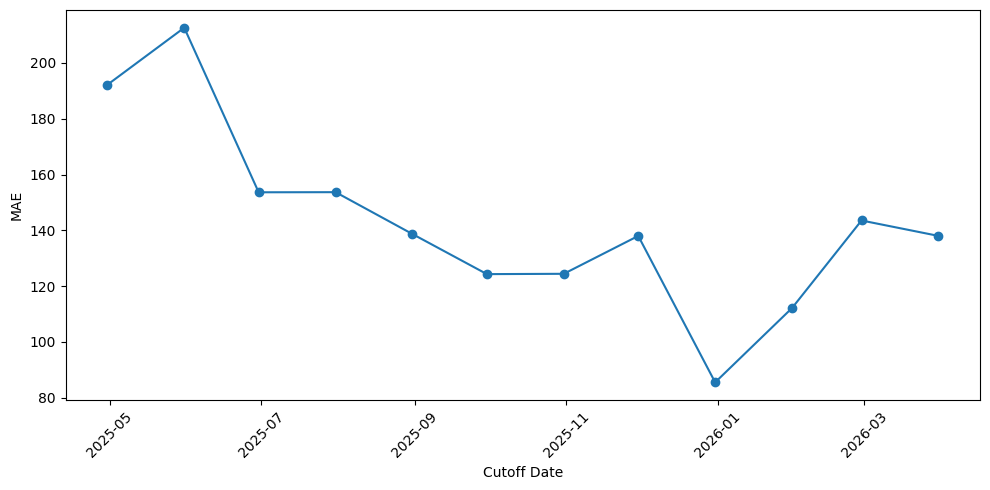

In [497]:
results_df["cutoff"] = pd.to_datetime(results_df["cutoff"])

plt.figure(figsize=(10, 5))
plt.plot(results_df["cutoff"], results_df["mae"], marker="o")
plt.xlabel("Cutoff Date")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

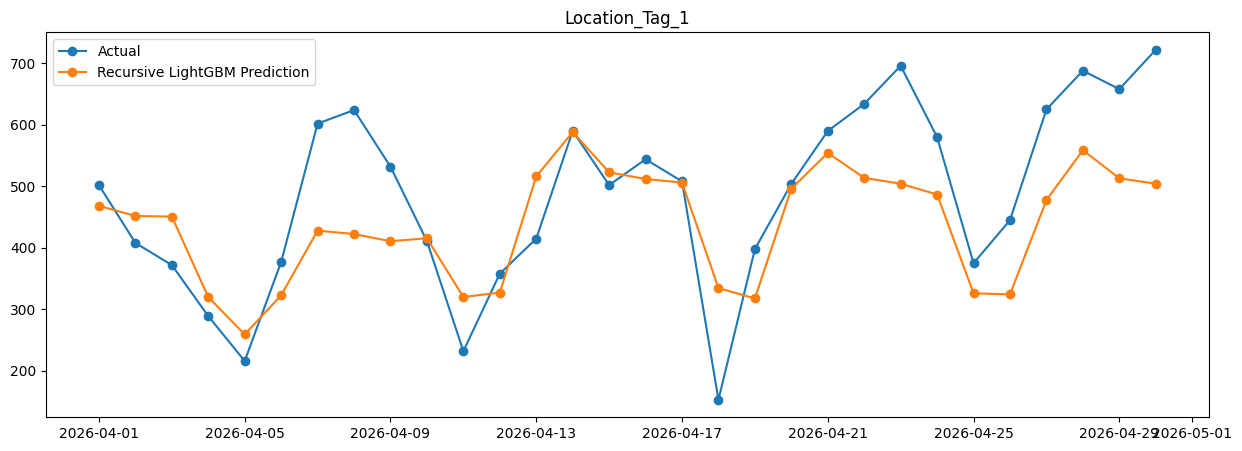

In [503]:
example_site = eval_df["Site_ID"].iloc[0]

plot_df = eval_df[eval_df["Site_ID"] == example_site].copy()

plt.figure(figsize=(15,5))
plt.plot(plot_df["Start_Time"], plot_df["actual"], label="Actual", marker="o")
plt.plot(plot_df["Start_Time"], plot_df["pred"], label="Recursive LightGBM Prediction", marker="o")

plt.title(example_site)
plt.legend()
plt.show()

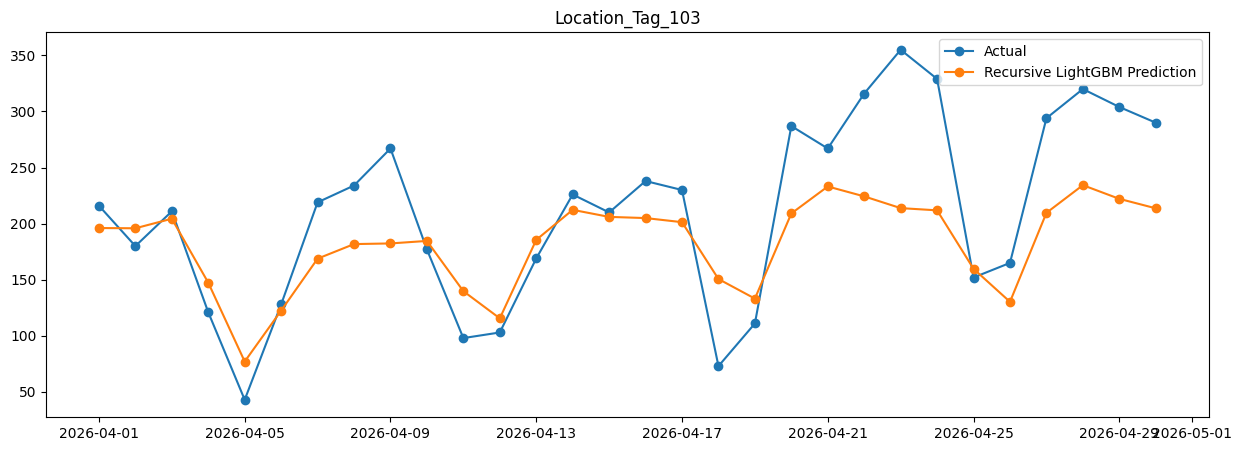

In [504]:
example_site = eval_df["Site_ID"].iloc[5]

plot_df = eval_df[eval_df["Site_ID"] == example_site].copy()

plt.figure(figsize=(15,5))
plt.plot(plot_df["Start_Time"], plot_df["actual"], label="Actual", marker="o")
plt.plot(plot_df["Start_Time"], plot_df["pred"], label="Recursive LightGBM Prediction", marker="o")

plt.title(example_site)
plt.legend()
plt.show()

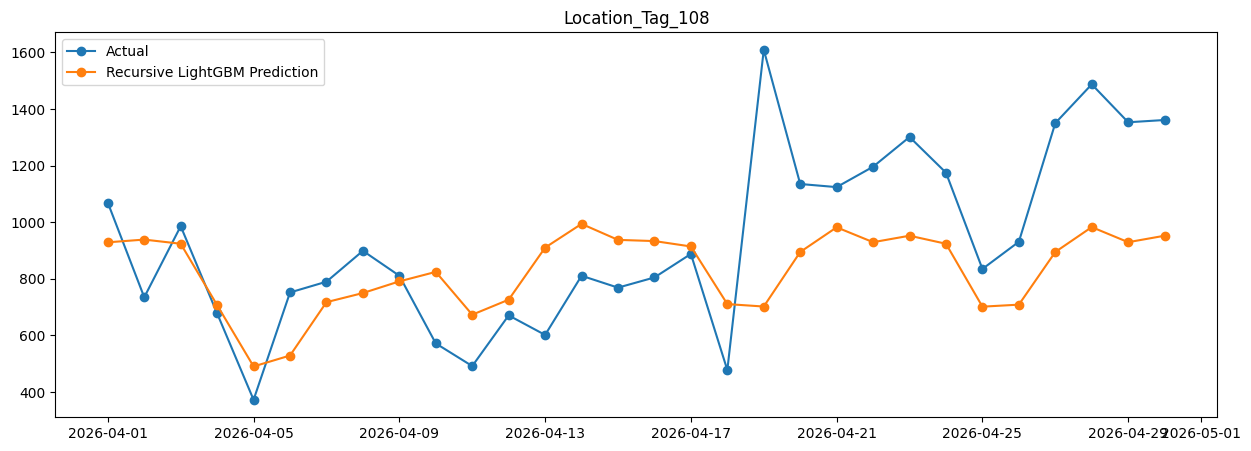

In [505]:
example_site = eval_df["Site_ID"].iloc[10]

plot_df = eval_df[eval_df["Site_ID"] == example_site].copy()

plt.figure(figsize=(15,5))
plt.plot(plot_df["Start_Time"], plot_df["actual"], label="Actual", marker="o")
plt.plot(plot_df["Start_Time"], plot_df["pred"], label="Recursive LightGBM Prediction", marker="o")

plt.title(example_site)
plt.legend()
plt.show()

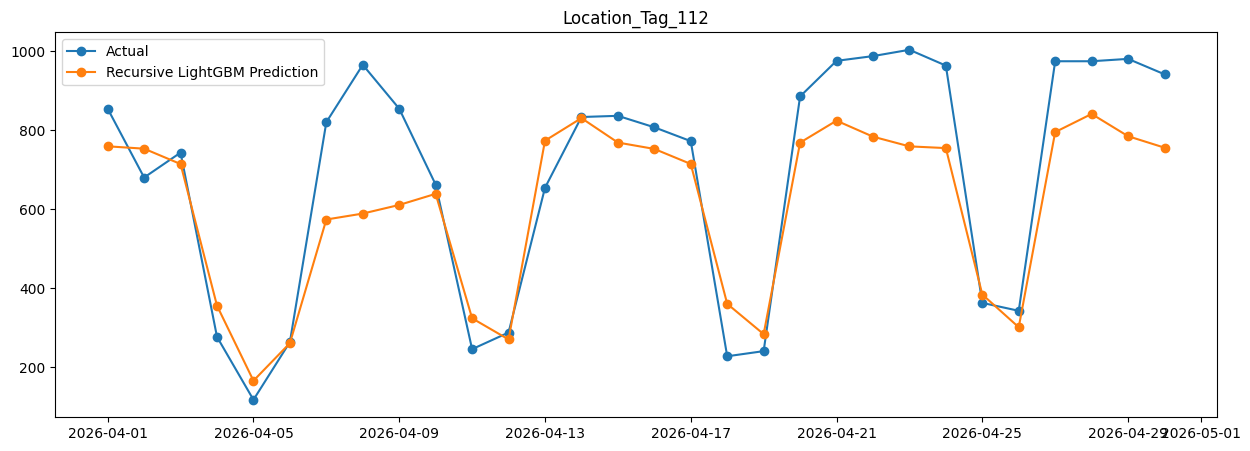

In [506]:
example_site = eval_df["Site_ID"].iloc[15]

plot_df = eval_df[eval_df["Site_ID"] == example_site].copy()

plt.figure(figsize=(15,5))
plt.plot(plot_df["Start_Time"], plot_df["actual"], label="Actual", marker="o")
plt.plot(plot_df["Start_Time"], plot_df["pred"], label="Recursive LightGBM Prediction", marker="o")

plt.title(example_site)
plt.legend()
plt.show()

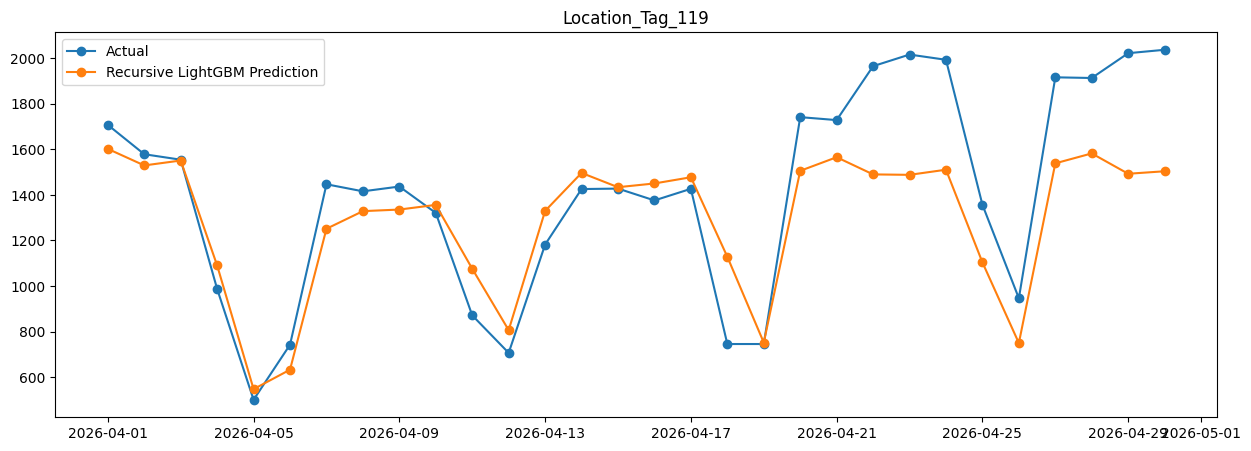

In [507]:
example_site = eval_df["Site_ID"].iloc[22]

plot_df = eval_df[eval_df["Site_ID"] == example_site].copy()

plt.figure(figsize=(15,5))
plt.plot(plot_df["Start_Time"], plot_df["actual"], label="Actual", marker="o")
plt.plot(plot_df["Start_Time"], plot_df["pred"], label="Recursive LightGBM Prediction", marker="o")

plt.title(example_site)
plt.legend()
plt.show()

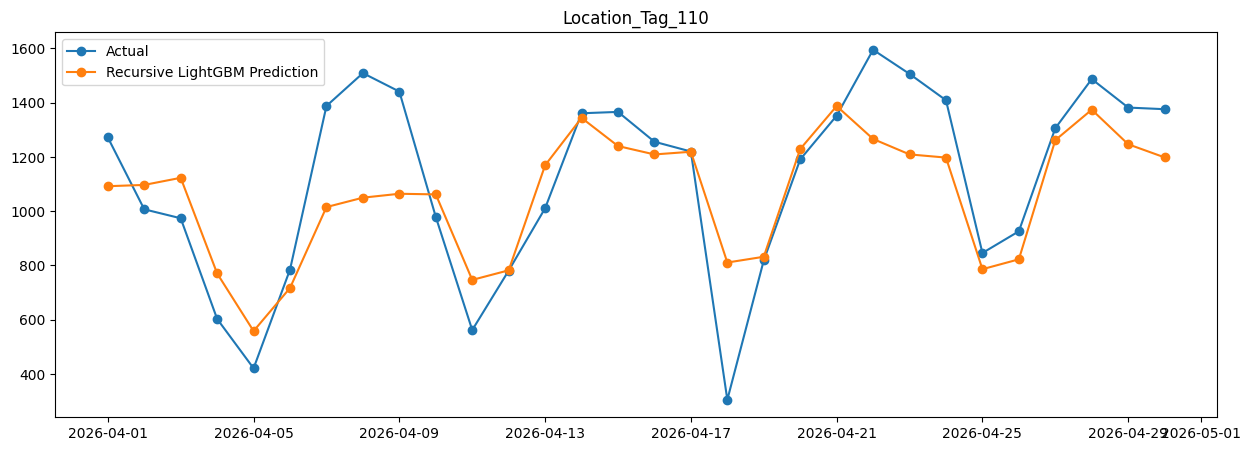

In [508]:
example_site = eval_df["Site_ID"].iloc[13]

plot_df = eval_df[eval_df["Site_ID"] == example_site].copy()

plt.figure(figsize=(15,5))
plt.plot(plot_df["Start_Time"], plot_df["actual"], label="Actual", marker="o")
plt.plot(plot_df["Start_Time"], plot_df["pred"], label="Recursive LightGBM Prediction", marker="o")

plt.title(example_site)
plt.legend()
plt.show()

In [421]:
def evaluate_one_cutoff(model, df, cutoff, forecast_end, features):
    cutoff = pd.Timestamp(cutoff)
    forecast_end = pd.Timestamp(forecast_end)

    test_actual = df[
        (df["Start_Time"] > cutoff) &
        (df["Start_Time"] <= forecast_end)
    ].copy()

    history = df[df["Start_Time"] <= cutoff][
        ["Site_ID", "Start_Time", "Count"]
    ].copy()

    future_dates = pd.date_range(
        start=cutoff + pd.Timedelta(days=1),
        end=forecast_end,
        freq="D"
    )

    pred_df = recursive_forecast_lgbm(
        model=model,
        history=history,
        future_dates=future_dates,
        features=features
    )

    eval_df = pred_df.merge(
        test_actual[["Site_ID", "Start_Time", "Count"]],
        on=["Site_ID", "Start_Time"],
        how="inner"
    )

    eval_df = eval_df.rename(columns={"Count": "actual"})

    mae = mean_absolute_error(eval_df["actual"], eval_df["pred"])
    rmse = np.sqrt(mean_squared_error(eval_df["actual"], eval_df["pred"]))

    return mae, rmse, eval_df

In [422]:
def evaluate_params(params, df, features, target, cutoffs, years=1):
    results = []

    for cutoff in cutoffs:
        cutoff_ts = pd.Timestamp(cutoff)
        forecast_end = cutoff_ts + pd.DateOffset(months=1)

        train, test_actual = split_train_test(
            df=df,
            cutoff=cutoff_ts,
            forecast_end=forecast_end,
            years=years
        )

        model = LGBMRegressor(
            **params,
            objective="regression",
            random_state=42,
            verbose=-1
        )

        model.fit(
            train[features],
            train[target],
            categorical_feature=["Site_ID"]
        )

        mae, rmse, _ = evaluate_one_cutoff(
            model=model,
            df=df,
            cutoff=cutoff_ts,
            forecast_end=forecast_end,
            features=features
        )

        results.append({
            "cutoff": cutoff_ts,
            "mae": mae,
            "rmse": rmse
        })

    results_df = pd.DataFrame(results)

    return {
        "params": params,
        "mean_mae": results_df["mae"].mean(),
        "mean_rmse": results_df["rmse"].mean(),
        "details": results_df
    }

## hourly

In [117]:
df_h.head()

,Site_ID,Start_Time,Count
0,Location_Tag_1,2023-05-18 20:00:00,16.0
1,Location_Tag_1,2023-05-18 21:00:00,8.0
2,Location_Tag_1,2023-05-18 22:00:00,1.0
3,Location_Tag_1,2023-05-18 23:00:00,3.0
4,Location_Tag_1,2023-05-19 00:00:00,1.0


In [472]:
features_h = [
    "Site_ID",
    "dayofweek",
    # "month",
    "dayofyear",
    "is_weekend",
    "Is_Public_Holiday",
    "hour",
    # "hour_sin",
    # "hour_cos",
    "lag_1h",
    "lag_2h",
    "lag_3h",
    "lag_24h",
    "lag_168h",
    "rolling_mean_3h",
    "rolling_mean_6h",
    "rolling_mean_24h"
]

target = "Count"

In [473]:
def add_time_features_h(data):
    data["dayofweek"] = data["Start_Time"].dt.dayofweek
    data["month"] = data["Start_Time"].dt.month
    data["dayofyear"] = data["Start_Time"].dt.dayofyear
    data["is_weekend"] = (data["dayofweek"] >= 5).astype(int)

    data["hour"] = data["Start_Time"].dt.hour
    data["hour_sin"] = np.sin(2 * np.pi * data["hour"] / 24)
    data["hour_cos"] = np.cos(2 * np.pi * data["hour"] / 24)
    
    return data

def add_time_lags_h(data):
    data["lag_1h"] = data.groupby("Site_ID")["Count"].shift(1)
    data["lag_2h"] = data.groupby("Site_ID")["Count"].shift(2)
    data["lag_3h"] = data.groupby("Site_ID")["Count"].shift(3)
    data["lag_24h"] = data.groupby("Site_ID")["Count"].shift(24)
    data["lag_168h"] = data.groupby("Site_ID")["Count"].shift(168)

    data["rolling_mean_3h"] = data.groupby("Site_ID")["Count"].shift(3).groupby(data["Site_ID"]).rolling(3).mean().reset_index(level=0, drop=True)
    data["rolling_mean_6h"] = data.groupby("Site_ID")["Count"].shift(6).groupby(data["Site_ID"]).rolling(6).mean().reset_index(level=0, drop=True)
    data["rolling_mean_24h"] = data.groupby("Site_ID")["Count"].shift(24).groupby(data["Site_ID"]).rolling(24).mean().reset_index(level=0, drop=True)
    
    return data


def recursive_forecast_lgbm_h(model, history, future_hours, features):
    history = history.copy()
    history["Start_Time"] = pd.to_datetime(history["Start_Time"])
    history = history.sort_values(["Site_ID", "Start_Time"])

    predictions = []

    sites = history["Site_ID"].unique()

    for current_time in future_hours:
        future_rows = pd.DataFrame({"Site_ID": sites, "Start_Time": current_time})
        future_rows = add_time_features_h(future_rows)
        future_rows = add_holiday_feature(future_rows)

        for lag in [1, 2, 3, 24, 168]:
            lag_values = (
                history[history["Start_Time"] == current_time - pd.Timedelta(hours=lag)][["Site_ID", "Count"]]
                .rename(columns={"Count": f"lag_{lag}h"})
            )

            future_rows = future_rows.merge(lag_values, on="Site_ID", how="left")

        rolling_features = []

        for site in sites:
            site_history = history[history["Site_ID"] == site].sort_values("Start_Time")

            past_counts = site_history["Count"].tail(24)

            rolling_features.append({
                "Site_ID": site,
                "rolling_mean_3h": past_counts.tail(3).mean(),
                "rolling_mean_6h": past_counts.tail(6).mean(),
                "rolling_mean_24h": past_counts.tail(24).mean()
            })

        rolling_df = pd.DataFrame(rolling_features)

        future_rows = future_rows.merge(rolling_df, on="Site_ID", how="left")

        required_cols = [
            "lag_1h",
            "lag_2h",
            "lag_3h",
            "lag_24h",
            "lag_168h",
            "rolling_mean_3h",
            "rolling_mean_6h",
            "rolling_mean_24h"
        ]

        future_rows = future_rows.dropna(subset=required_cols).copy()

        if future_rows.empty:
            continue

        future_rows["Site_ID"] = future_rows["Site_ID"].astype("category")
        future_rows["pred"] = model.predict(future_rows[features])
        future_rows["pred"] = np.maximum(future_rows["pred"], 0)
        append_rows = future_rows[["Site_ID", "Start_Time", "pred"]].rename(
            columns={"pred": "Count"}
        )

        history = pd.concat([history, append_rows], ignore_index=True)
        predictions.append(future_rows)

    if len(predictions) == 0:
        return pd.DataFrame()

    return pd.concat(predictions, ignore_index=True)


def predict_count_h(lgbm_model,test_actual,df,cutoff="2025-05-16",forecast_end="2025-11-16"):

    future_hours = pd.date_range(
        start=pd.Timestamp(cutoff) + pd.Timedelta(hours=1),
        end=pd.Timestamp(forecast_end),
        freq="h"
    )

    history = df[df["Start_Time"] <= cutoff][["Site_ID", "Start_Time", "Count"]]

    pred_eval = recursive_forecast_lgbm_h(
        model=lgbm_model,
        history=history,
        future_hours=future_hours,
        features=features_h
    )

    eval_df = pred_eval.merge(
        test_actual[["Site_ID", "Start_Time", "Count"]],
        on=["Site_ID", "Start_Time"],
        how="inner"
    )

    eval_df = eval_df.rename(columns={"Count": "actual"})

    mae_lgbm = mean_absolute_error(eval_df["actual"], eval_df["pred"])
    rmse_lgbm = np.sqrt(mean_squared_error(eval_df["actual"], eval_df["pred"]))

    print("Recursive LightGBM MAE:", mae_lgbm)
    print("Recursive LightGBM RMSE:", rmse_lgbm)

    return eval_df


In [474]:
df_h = add_time_features_h(df_h)
df_h = add_time_lags_h(df_h)
df_h = add_holiday_feature(df_h)

In [475]:
df_model_h = df_h.dropna().copy()

In [476]:
df_model_h.head()

,Site_ID,Start_Time,Count,dayofweek,month,dayofyear,is_weekend,hour,hour_sin,hour_cos,lag_1h,lag_2h,lag_3h,lag_24h,lag_168h,rolling_mean_3h,rolling_mean_6h,rolling_mean_24h,Is_Public_Holiday
168,Location_Tag_1,2023-05-26 16:00:00,62.0,4,5,146,0,16,-0.866025,-5.000000e-01,47.0,31.0,29.0,62.0,3.0,32.000000,26.500000,28.250000,0
169,Location_Tag_1,2023-05-26 17:00:00,46.0,4,5,146,0,17,-0.965926,-2.588190e-01,62.0,47.0,31.0,70.0,31.0,35.000000,28.833333,28.625000,0
170,Location_Tag_1,2023-05-26 18:00:00,40.0,4,5,146,0,18,-1.000000,-1.836970e-16,46.0,62.0,47.0,43.0,41.0,35.666667,31.333333,28.000000,0
171,Location_Tag_1,2023-05-26 19:00:00,31.0,4,5,146,0,19,-0.965926,2.588190e-01,40.0,46.0,62.0,25.0,23.0,46.666667,27.000000,26.708333,0
172,Location_Tag_1,2023-05-26 20:00:00,24.0,4,5,146,0,20,-0.866025,5.000000e-01,31.0,40.0,46.0,25.0,11.0,51.666667,25.666667,27.208333,0


In [477]:
cutoff="2025-12-31"
forecast_end="2026-01-31"

In [478]:
train_2Y_h, test_actual_2Y_h = split_train_test(df=df_model_h, years=1, cutoff=cutoff, forecast_end=forecast_end)

In [479]:
lgbm_model_2Y_h = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    random_state=42
)

lgbm_model_2Y_h.fit(
    train_2Y_h[features_h],
    train_2Y_h[target],
    categorical_feature=["Site_ID"]
)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [480]:
feature_importance = pd.DataFrame({
    "feature": features_h,
    "importance": lgbm_model_2Y_h.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
5,hour,2151
0,Site_ID,2070
6,lag_1h,1957
10,lag_168h,1722
9,lag_24h,1497
2,dayofyear,1427
1,dayofweek,1078
12,rolling_mean_6h,839
11,rolling_mean_3h,705
7,lag_2h,697


In [481]:
eval_df_2Y_h = predict_count_h(lgbm_model_2Y_h, test_actual_2Y_h, df_model_h)

KeyboardInterrupt: 